/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-2129.726807,159.384003,-66.031405,105.040158,15457,21.039378
2,-296.574768,204.295990,11.796151,88.541499,14302,19.467244
3,-246.101562,218.857208,53.859910,83.989987,14235,19.376046
4,-204.534866,249.638596,93.977654,79.207554,14302,19.467244
5,-154.461487,389.430328,158.863673,75.914138,15171,20.650088


Returns Analysis


,1D,5D,10D
Ann. alpha,0.188,0.191,0.199
beta,-0.012,-0.002,0.019
Mean Period Wise Return Top Quantile (bps),9.824,9.548,10.149
Mean Period Wise Return Bottom Quantile (bps),-3.632,-5.874,-6.904
Mean Period Wise Spread (bps),13.456,15.134,16.634


<Figure size 640x480 with 0 Axes>

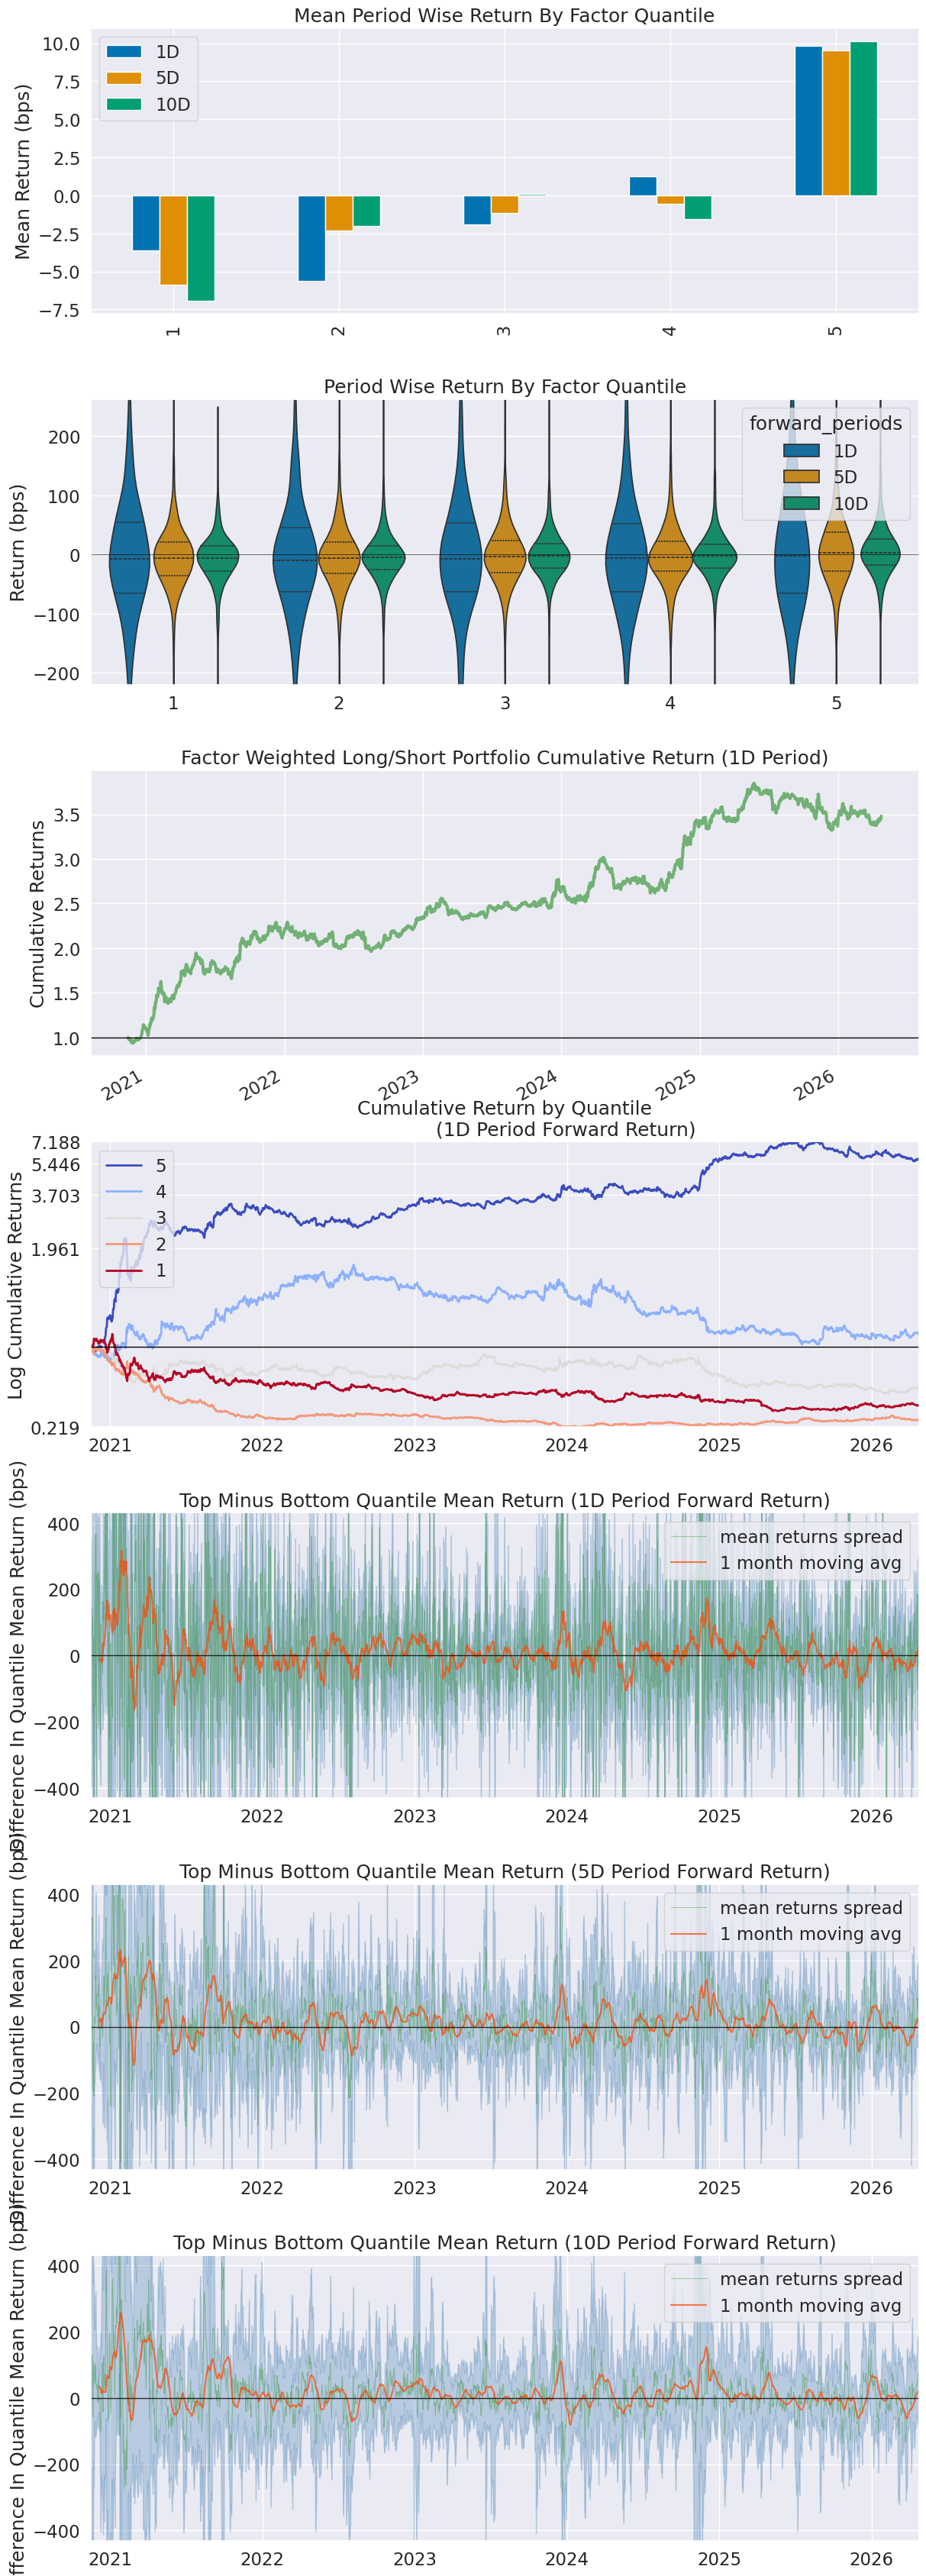

Information Analysis


,1D,5D,10D
IC Mean,0.001,0.008,0.017
IC Std.,0.199,0.202,0.197
Risk-Adjusted IC,0.004,0.038,0.088
t-stat(IC),0.195,1.675,3.913
p-value(IC),0.845,0.094,0.000
IC Skew,-0.037,-0.033,-0.103
IC Kurtosis,-0.179,-0.211,-0.137


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


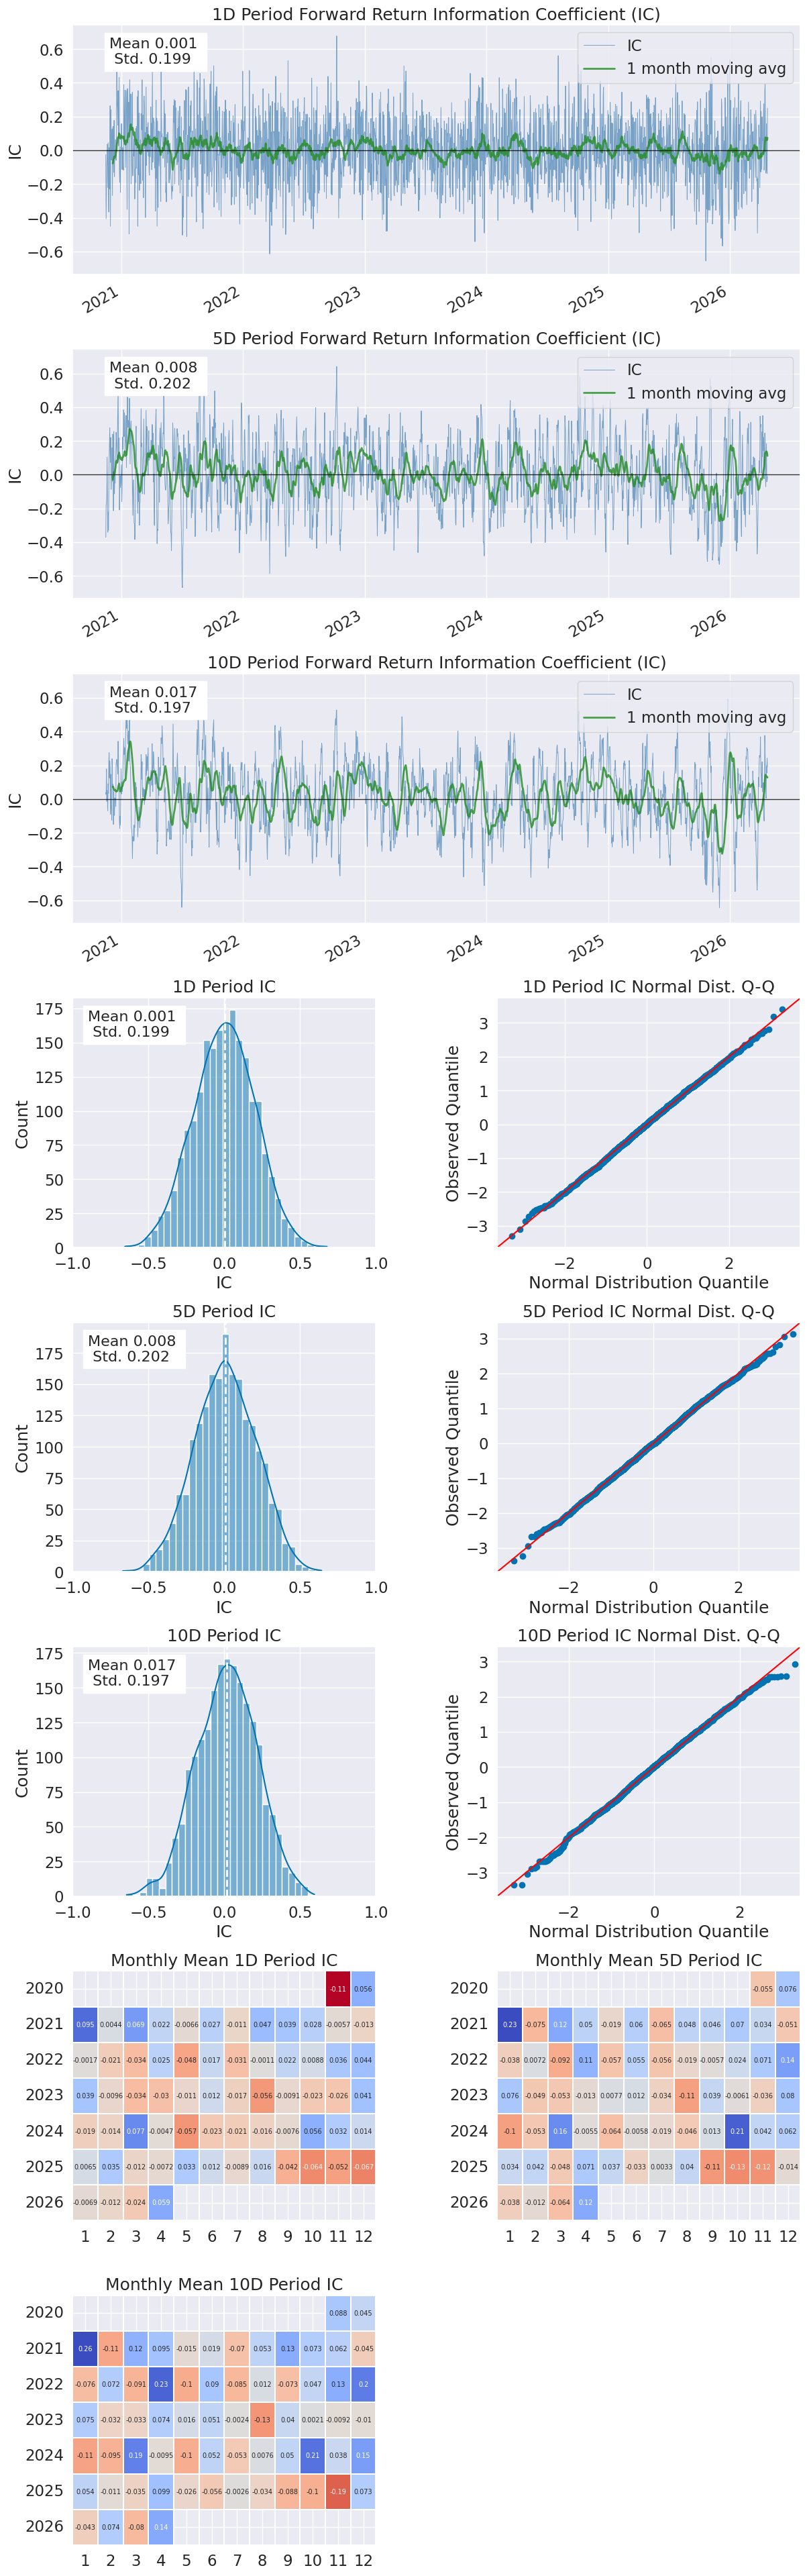

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.114,0.352,0.540
Quantile 2 Mean Turnover,0.255,0.610,0.740
Quantile 3 Mean Turnover,0.292,0.655,0.761
Quantile 4 Mean Turnover,0.260,0.628,0.744
Quantile 5 Mean Turnover,0.124,0.390,0.587


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.978,0.786,0.507


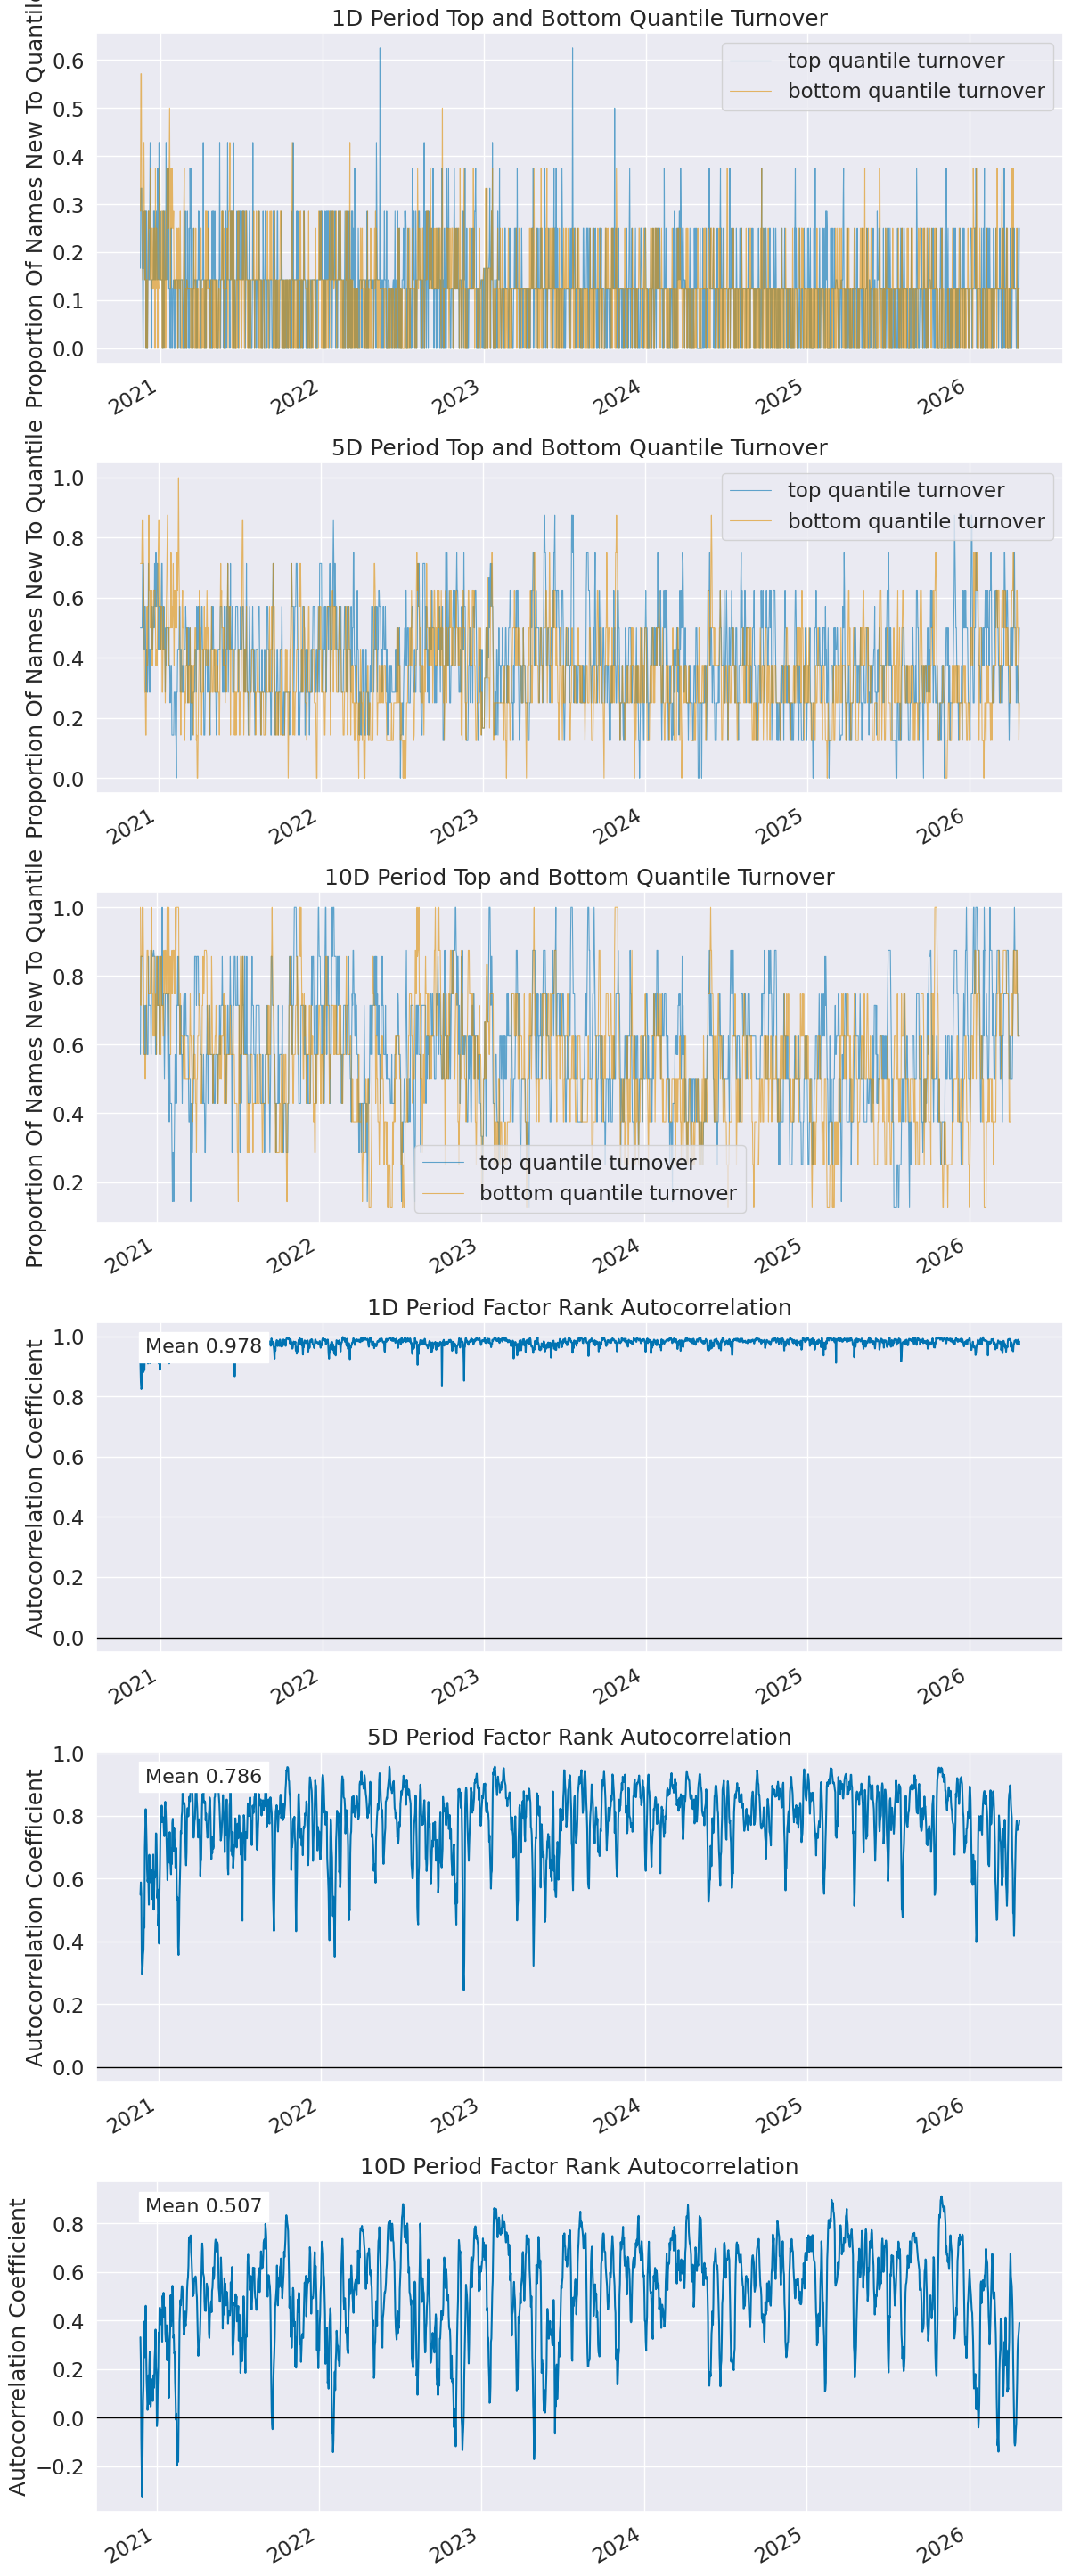

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from aperiodic import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

APERIODIC_API_KEY = get_env("APERIODIC_API_KEY")

# Retail Flow -- portfolio retail_flow.40
portfolio = "retail_flow"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=APERIODIC_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=APERIODIC_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=APERIODIC_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=APERIODIC_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)